# Joint expected coverage and marginal SBC

The official-style 300-case dataset is kept separate from the powered
1,024-case sensitivity set. Joint HPD ranks use posterior density, while
marginal SBC ranks test each inferred coordinate. Individual networks and the
raw equal-weight ensemble are reported separately.

In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "S4_sbi").exists() else cwd.parent.parent
SRC = PROJECT_ROOT / "S4_sbi" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
RESULTS = PROJECT_ROOT / "S4_sbi" / "results" / "figure10_8d_7d"
assert os.environ.get("CONDA_DEFAULT_ENV") == "neurolib"
print("environment:", os.environ.get("CONDA_DEFAULT_ENV"))
print("python:", sys.executable)
print("results:", RESULTS)

environment: neurolib
python: C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe
results: D:\Year3_Mao_Projects\sleep_loop\S4_sbi\results\figure10_8d_7d


## Machine-readable summaries

`holm_clear_issue` is a project reproducibility operationalization, not an
official Figure 10 threshold. Visual rank curves remain the primary
official-style presentation.

In [2]:
rows = []
sbc = []
for dataset_id in ("official_300", "powered_1024"):
    for track in ("8d", "7d"):
        root = RESULTS / "diagnostics" / "global" / dataset_id / track / "scale_32768"
        frame = pd.read_csv(root / "global_summary.csv")
        frame["analysis"] = dataset_id
        rows.append(frame)
        detail = pd.read_csv(root / "marginal_sbc_summary.csv")
        detail["analysis"] = dataset_id
        sbc.append(detail)
global_table = pd.concat(rows, ignore_index=True)
sbc_table = pd.concat(sbc, ignore_index=True)
display(global_table)
display(sbc_table[(sbc_table.analysis == "powered_1024") & (sbc_table.estimator == "ensemble")])

,dataset_id,track,scale,estimator,cases,joint_rank_ks_statistic,joint_rank_ks_pvalue,mean_posterior_median_abs_error,prior_median_abs_error,recovery_improvement_fraction,median_normalized_posterior_sd,analysis
0,official_300,8d,32768,ensemble,300,0.189001,7.400491e-10,0.144712,0.249931,0.420993,0.638216,official_300
1,official_300,8d,32768,member_1,300,0.030569,9.337081e-01,0.147075,0.249931,0.411539,0.634824,official_300
2,official_300,8d,32768,member_2,300,0.053736,3.395966e-01,0.144749,0.249931,0.420844,0.640342,official_300
3,official_300,8d,32768,member_3,300,0.084349,2.636710e-02,0.142796,0.249931,0.428657,0.595204,official_300
4,official_300,8d,32768,member_4,300,0.050556,4.135826e-01,0.148304,0.249931,0.406620,0.657568,official_300
5,official_300,8d,32768,member_5,300,0.038921,7.385514e-01,0.146920,0.249931,0.412158,0.644638,official_300
6,official_300,7d,32768,ensemble,300,0.203430,2.314770e-11,0.126239,0.249951,0.494945,0.599072,official_300
7,official_300,7d,32768,member_1,300,0.030027,9.420727e-01,0.128178,0.249951,0.487189,0.574440,official_300
8,official_300,7d,32768,member_2,300,0.034033,8.659528e-01,0.121999,0.249951,0.511908,0.560605,official_300
9,official_300,7d,32768,member_3,300,0.064845,1.535098e-01,0.129088,0.249951,0.483548,0.593789,official_300


,dataset_id,track,scale,estimator,parameter,ks_statistic,ks_pvalue,rank_mean,rank_variance,bias_mean,normalized_posterior_sd_median,holm_clear_issue,analysis
90,powered_1024,8d,32768,ensemble,mue,0.071578,5.237742e-05,0.520694,0.100618,-0.017265,0.553330,True,powered_1024
91,powered_1024,8d,32768,ensemble,mui,0.252459,5.235035e-58,0.589638,0.035498,-0.002453,0.049447,True,powered_1024
92,powered_1024,8d,32768,ensemble,b,0.020284,7.854500e-01,0.507050,0.084676,-0.001417,0.385687,False,powered_1024
93,powered_1024,8d,32768,ensemble,tauA,0.072194,4.364710e-05,0.524684,0.100268,-0.019171,0.725878,True,powered_1024
94,powered_1024,8d,32768,ensemble,g_LK,0.029172,3.415822e-01,0.496407,0.089604,0.028603,0.616592,False,powered_1024
95,powered_1024,8d,32768,ensemble,g_h,0.022730,6.566699e-01,0.507144,0.085820,0.017167,0.719386,False,powered_1024
96,powered_1024,8d,32768,ensemble,c_th2ctx,0.046029,2.528042e-02,0.494340,0.095127,-0.043500,0.654829,False,powered_1024
97,powered_1024,8d,32768,ensemble,c_ctx2th,0.012775,9.954908e-01,0.498655,0.084050,0.000894,0.994294,False,powered_1024
138,powered_1024,7d,32768,ensemble,mue,0.076663,1.111061e-05,0.518899,0.100987,-0.012004,0.551955,True,powered_1024
139,powered_1024,7d,32768,ensemble,mui,0.184393,6.020374e-31,0.460755,0.038364,0.001225,0.031279,True,powered_1024


## Figure

The diagonal is ideal calibration. Systematic curvature indicates
miscalibration; a broad marginal can still be calibrated. The shaded region is
the finite-sample uncertainty band for the powered analysis.

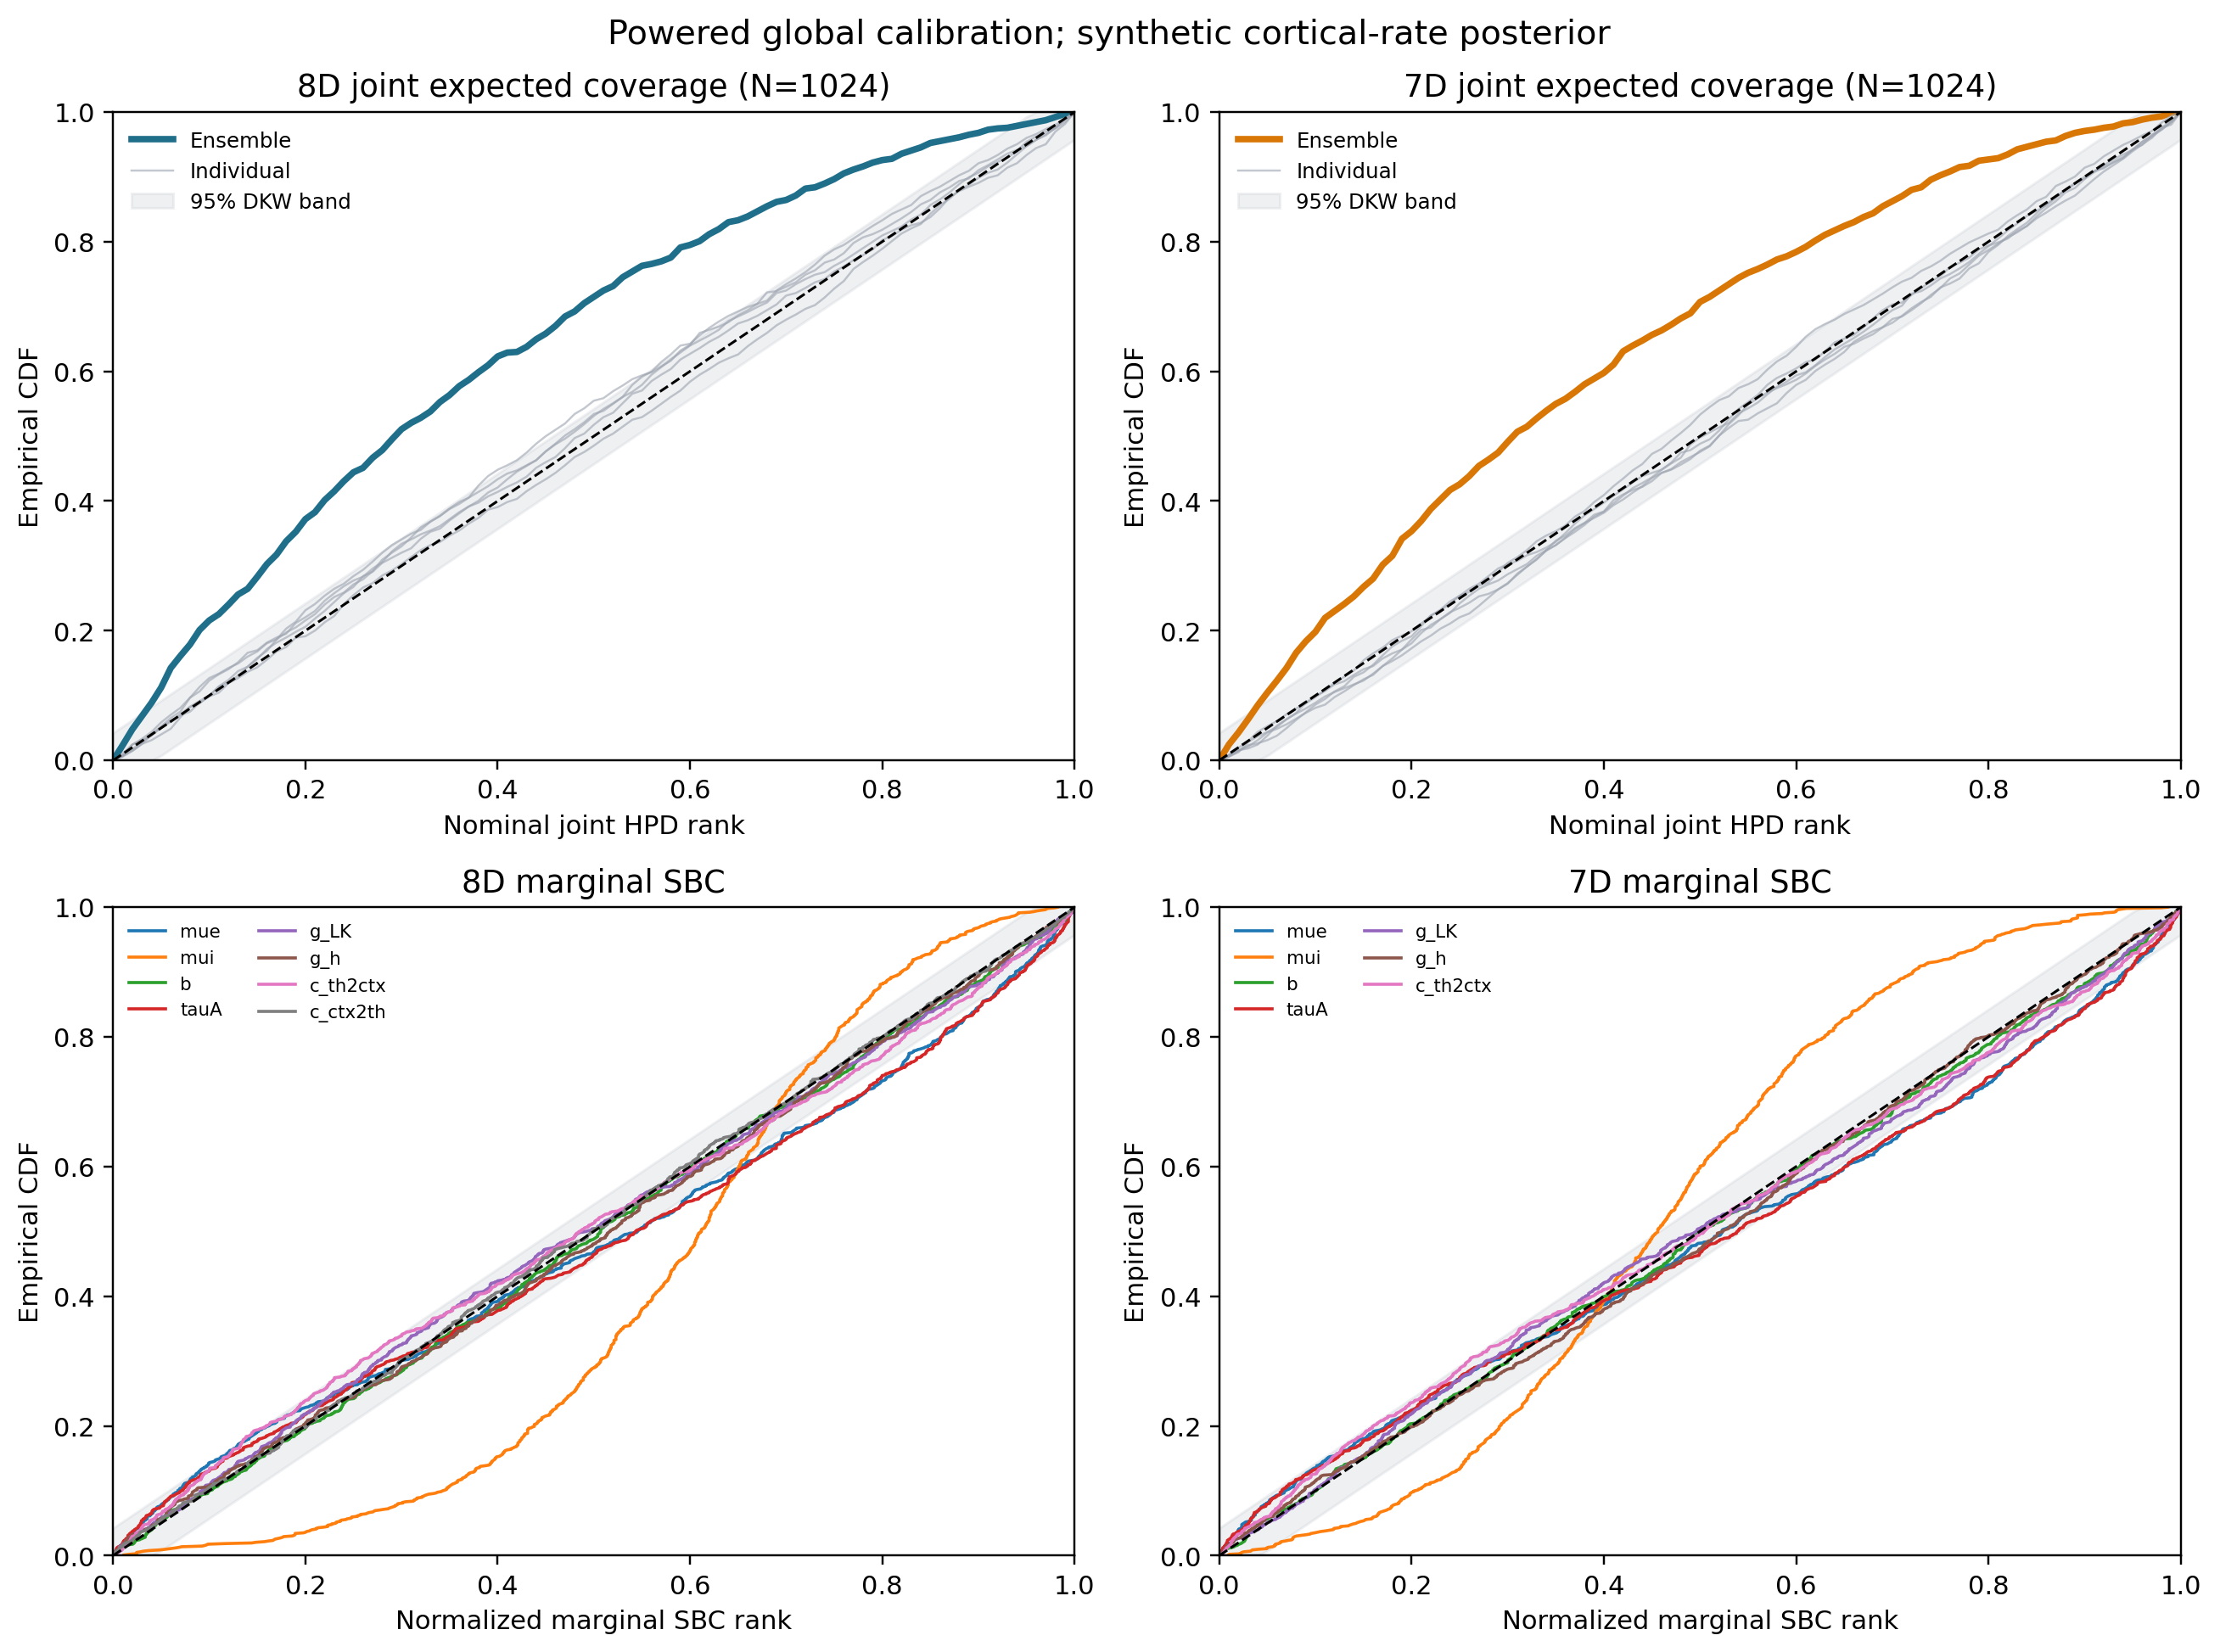

In [3]:
figure = RESULTS / "figures" / "figure10_expected_coverage_sbc_8d_7d.png"
assert figure.exists() and figure.stat().st_size > 1000
display(Image(filename=str(figure)))